# 04 - RNN Forecasting Model

- Version 1.03  
- updated 04.05.26

A Simple Recurrent Neural Network (RNN) baseline.

RNNs process sequences step-by-step, passing a hidden state forward at each
timestep. They are the predecessor to LSTM and share the same core concept,
but suffer from the **vanishing gradient problem** -- they struggle to learn
patterns that span many timesteps.

This notebook exists to demonstrate WHY LSTM was invented, by establishing
an RNN baseline to compare directly against LSTM results.

| Model | Key difference |
|-------|---------------|
| Simple RNN | Single hidden state, short memory |
| LSTM | Cell state + gates, long-term memory |

## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import mlflow
import sys
sys.path.append(r'Q:\scripts\projects\ts-model-framework')
import config

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

mlflow.set_tracking_uri(config.MLFLOW_URI)
mlflow.set_experiment(config.EXPERIMENT)

print(f"Device: {device}")
print("Libraries loaded.")

Device: cuda
Libraries loaded.


---
## S1 - Load & Scale Data  
Identical preprocessing to 03_LSTM.ipynb.  
Scaler fit on train only to prevent data leakage.  

In [2]:
# FILE_NAME     = "timeseries_with_features.csv"
# DATE_COLUMN   = "date"
# TARGET_COLUMN = "unit_sales"
TEST_START    = "2014-01-01"

file_path = os.path.join(config.DATA_PATH, config.FILE_NAME)
df = pd.read_csv(file_path, parse_dates=[config.DATE_COLUMN], index_col=config.DATE_COLUMN)
df = df.sort_index()

df_train = df[df.index < TEST_START][[config.TARGET_COLUMN]].fillna(0)
df_test  = df[df.index >= TEST_START][[config.TARGET_COLUMN]].fillna(0)

scaler       = MinMaxScaler()
train_scaled = scaler.fit_transform(df_train)
test_scaled  = scaler.transform(df_test)

print(f"Train: {df_train.shape} | Test: {df_test.shape}")
print(f"Device: {device}")

Train: (363, 1) | Test: (89, 1)
Device: cuda


---
## S2 - Build Sequences  
Same sliding window approach as LSTM.  
SEQUENCE_LENGTH controls how many past timesteps the model sees per prediction.  

In [3]:
SEQUENCE_LENGTH = 30

def make_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i - seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train_np, y_train_np = make_sequences(train_scaled, SEQUENCE_LENGTH)
X_test_np,  y_test_np  = make_sequences(test_scaled,  SEQUENCE_LENGTH)

X_train_np = X_train_np.reshape(-1, SEQUENCE_LENGTH, 1)
X_test_np  = X_test_np.reshape(-1, SEQUENCE_LENGTH, 1)

X_train_t = torch.FloatTensor(X_train_np).to(device)
y_train_t = torch.FloatTensor(y_train_np).to(device)
X_test_t  = torch.FloatTensor(X_test_np).to(device)
y_test_t  = torch.FloatTensor(y_test_np).to(device)

print(f"X_train: {X_train_np.shape} | X_test: {X_test_np.shape}")

X_train: (333, 30, 1) | X_test: (59, 30, 1)


---
## S3 - Define Simple RNN Model  
nn.RNN is PyTorch's built-in RNN layer.  
Notice how similar the architecture is to LSTM --  
the key difference is internal: RNN has no cell state or gates.  

In [4]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        rnn_out, _ = self.rnn(x)
        return self.fc(rnn_out[:, -1, :])

HIDDEN_SIZE   = 64
EPOCHS        = 50
LEARNING_RATE = 0.001
BATCH_SIZE    = 32
patience      = 15

model     = SimpleRNN(hidden_size=HIDDEN_SIZE).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

SimpleRNN(
  (rnn): RNN(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 4,353


---
## S4 - Train RNN Baseline  
Watch the loss curve -- RNNs often plateau earlier than LSTMs  
due to the vanishing gradient problem.  

In [5]:
train_losses   = []
best_loss      = float('inf')
patience_count = 0

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=False
)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch).squeeze()
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    if avg_loss < best_loss:
        best_loss      = avg_loss
        patience_count = 0
    else:
        patience_count += 1

    if patience_count >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.6f}")

print("Training complete.")

Epoch 10/50 | Loss: 0.020072
Epoch 20/50 | Loss: 0.011052
Epoch 30/50 | Loss: 0.010401
Epoch 40/50 | Loss: 0.010145
Epoch 50/50 | Loss: 0.009789
Training complete.


---
## S5 - Evaluate & Log Baseline to MLflow  

In [6]:
params = {
    "sequence_length": SEQUENCE_LENGTH,
    "hidden_size":     HIDDEN_SIZE,
    "epochs":          EPOCHS,
    "learning_rate":   LEARNING_RATE,
    "batch_size":      BATCH_SIZE
}

with mlflow.start_run(run_name="rnn-baseline"):
    model.eval()
    with torch.no_grad():
        preds_scaled = model(X_test_t).squeeze().cpu().numpy()

    preds   = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    actuals = scaler.inverse_transform(y_test_np.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    mape = np.mean(np.abs((actuals - preds) / actuals)) * 100
    r2   = 1 - (np.sum((actuals - preds)**2) / np.sum((actuals - np.mean(actuals))**2))
    bias = np.mean(preds - actuals)

    mlflow.log_params(params)
    mlflow.log_metrics({"rmse": rmse, "mae": mae, "mape": mape, "r2": r2, "bias": bias})

    print(f"RNN Baseline Results:")
    print(f"  RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.2f}% | R²: {r2:.4f} | Bias: {bias:.2f}")

RNN Baseline Results:
  RMSE: 108.75 | MAE: 85.48 | MAPE: 22.60% | R²: 0.5039 | Bias: 21.24
🏃 View run rnn-baseline at: http://localhost:5000/#/experiments/2/runs/d85e23b1bb7a438990801d37d6a2d248
🧪 View experiment at: http://localhost:5000/#/experiments/2


---
## S6 - Hyperopt Tuning

In [7]:
search_space = {
    'hidden_size':   hp.choice('hidden_size',  [32, 64, 128]),
    'learning_rate': hp.loguniform('lr',       np.log(1e-4), np.log(1e-2)),
    'batch_size':    hp.choice('batch_size',   [8, 16, 32]),
}

def objective(params):
    hidden_size   = params['hidden_size']
    learning_rate = params['learning_rate']
    batch_size    = int(params['batch_size'])

    trial_model  = SimpleRNN(hidden_size=hidden_size).to(device)
    trial_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_size=batch_size,
        shuffle=False
    )

    trial_criterion = nn.MSELoss()
    trial_optimizer = torch.optim.Adam(trial_model.parameters(), lr=learning_rate)
    best_loss, patience_count = float('inf'), 0

    for epoch in range(100):
        trial_model.train()
        epoch_loss = 0
        for X_batch, y_batch in trial_loader:
            trial_optimizer.zero_grad()
            preds = trial_model(X_batch).squeeze()
            loss  = trial_criterion(preds, y_batch)
            loss.backward()
            trial_optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(trial_loader)
        if avg_loss < best_loss:
            best_loss, patience_count = avg_loss, 0
        else:
            patience_count += 1
        if patience_count >= 10:
            break

    return {'loss': best_loss, 'status': STATUS_OK, 'params': params}

trials      = Trials()
best_params = fmin(fn=objective, space=search_space, algo=tpe.suggest,
                   max_evals=20, trials=trials)

print(f"\nBest params found:")
print(f"  hidden_size:   {[32, 64, 128][best_params['hidden_size']]}")
print(f"  learning_rate: {best_params['lr']:.6f}")
print(f"  batch_size:    {[8, 16, 32][best_params['batch_size']]}")

100%|██████████| 20/20 [01:34<00:00,  4.75s/trial, best loss: 0.008293344385244629]

Best params found:
  hidden_size:   32
  learning_rate: 0.001786
  batch_size:    32


---
## S7 - Retrain & Log Tuned RNN

In [8]:
tuned_params = {
    "hidden_size":     [32, 64, 128][best_params['hidden_size']],
    "learning_rate":   best_params['lr'],
    "batch_size":      [8, 16, 32][best_params['batch_size']],
    "sequence_length": SEQUENCE_LENGTH,
    "epochs":          EPOCHS
}

tuned_loader    = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=tuned_params['batch_size'],
    shuffle=False
)
tuned_model     = SimpleRNN(hidden_size=tuned_params['hidden_size']).to(device)
tuned_criterion = nn.MSELoss()
tuned_optimizer = torch.optim.Adam(tuned_model.parameters(), lr=tuned_params['learning_rate'])

best_loss, patience_count = float('inf'), 0
for epoch in range(EPOCHS):
    tuned_model.train()
    epoch_loss = 0
    for X_batch, y_batch in tuned_loader:
        tuned_optimizer.zero_grad()
        preds = tuned_model(X_batch).squeeze()
        loss  = tuned_criterion(preds, y_batch)
        loss.backward()
        tuned_optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(tuned_loader)
    if avg_loss < best_loss:
        best_loss, patience_count = avg_loss, 0
    else:
        patience_count += 1
    if patience_count >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

with mlflow.start_run(run_name="rnn-tuned"):
    tuned_model.eval()
    with torch.no_grad():
        preds_scaled = tuned_model(X_test_t).squeeze().cpu().numpy()

    preds   = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
    actuals = scaler.inverse_transform(y_test_np.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    mape = np.mean(np.abs((actuals - preds) / actuals)) * 100
    r2   = 1 - (np.sum((actuals - preds)**2) / np.sum((actuals - np.mean(actuals))**2))
    bias = np.mean(preds - actuals)

    mlflow.log_params(tuned_params)
    mlflow.log_metrics({"rmse": rmse, "mae": mae, "mape": mape, "r2": r2, "bias": bias})

    print(f"RNN Tuned Results:")
    print(f"  RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.2f}% | R²: {r2:.4f} | Bias: {bias:.2f}")

RNN Tuned Results:
  RMSE: 108.31 | MAE: 84.67 | MAPE: 22.39% | R²: 0.5080 | Bias: 22.85
🏃 View run rnn-tuned at: http://localhost:5000/#/experiments/2/runs/57b42dda48d44fe49adf204b1b75b67f
🧪 View experiment at: http://localhost:5000/#/experiments/2


---
## S8 - Save Tuned RNN Model

In [9]:
# S8 - Save Tuned RNN Model
import torch

rnn_save_path = os.path.join(config.MODELS_PATH, 'best_rnn_model.pt')
torch.save(tuned_model.state_dict(), rnn_save_path)

# Save model name
name_path = os.path.join(config.MODELS_PATH, 'best_rnn_model_name.txt')
with open(name_path, 'w') as f:
    f.write(f"rnn-tuned | RMSE: {rmse:.2f} | MAE: {mae:.2f}")

print(f"RNN model saved: {rnn_save_path}")
print(f"RMSE: {rmse:.2f} | MAE: {mae:.2f}")

RNN model saved: Q:\scripts\projects\ts-model-framework\models\best_rnn_model.pt
RMSE: 108.31 | MAE: 84.67


---
## S9 - Training Loss & Forecast Plot

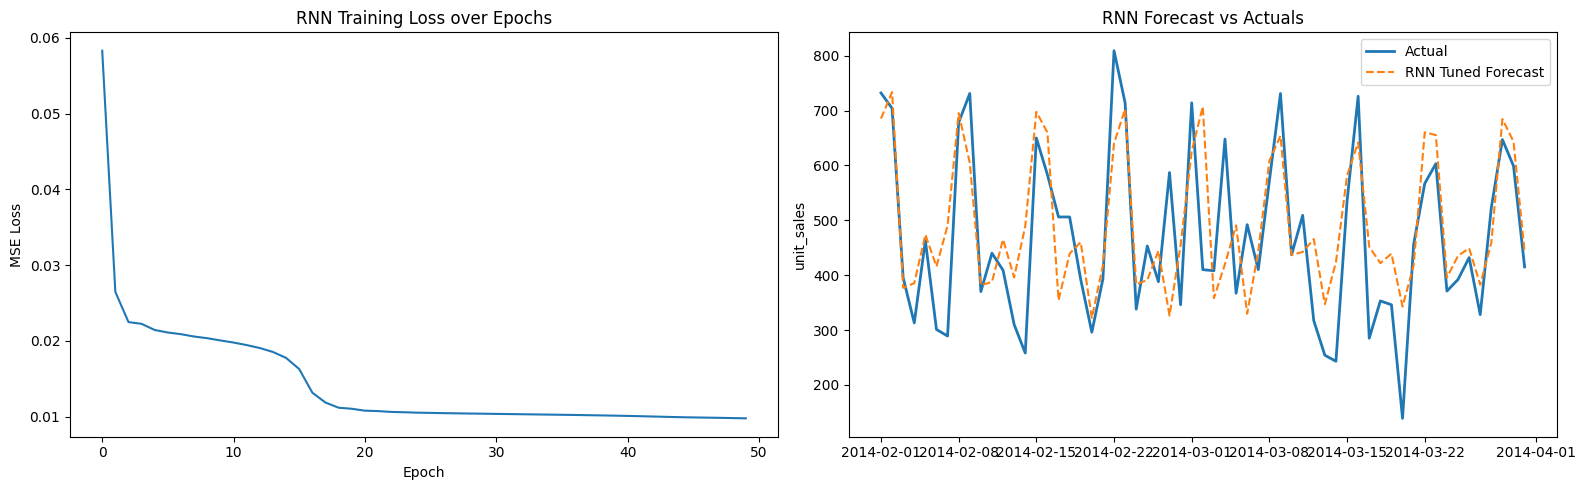

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(train_losses)
axes[0].set_title('RNN Training Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')

test_dates = df_test.index[SEQUENCE_LENGTH:]
axes[1].plot(test_dates, actuals, label='Actual', linewidth=2)
axes[1].plot(test_dates, preds,   label='RNN Tuned Forecast', linestyle='--')
axes[1].set_title('RNN Forecast vs Actuals')
axes[1].set_ylabel(config.TARGET_COLUMN)
axes[1].legend()

plt.tight_layout()
plt.show()

---
## S10 - Notes & Observations

- Early stopping triggered at epoch:
- RNN baseline RMSE vs LSTM baseline (127.09):
- RNN tuned RMSE vs LSTM tuned:
- Loss curve behavior vs LSTM (did it plateau earlier?):
- Vanishing gradient evidence observed:
- Next experiment to try: